In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from narwhals.selectors import categorical
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
import shap
import optuna
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
application_train = pd.read_csv("train_features_more_predictors.csv")
application_test = pd.read_csv("test_features_more_predictors.csv")

In [3]:
application_train.shape

(307511, 220)

In [4]:
application_test.shape

(48744, 219)

In [5]:
application_train.head()

,Unnamed: 0,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,...,prev_critical_reject_last2,prev_approval_rate_last3,prev_refused_last3,prev_avg_credit_last3,prev_critical_reject_last3,prev_approval_rate_last5,prev_refused_last5,prev_avg_credit_last5,prev_critical_reject_last5,prev_approval_trend
0,0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,...,0.0,1.000000,0.0,179055.0,0.0,1.0,0.0,179055.0,0.0,0.000000
1,1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,...,0.0,1.000000,0.0,484191.0,0.0,1.0,0.0,484191.0,0.0,0.000000
2,2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,...,0.0,1.000000,0.0,20106.0,0.0,1.0,0.0,20106.0,0.0,0.000000
3,3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,...,1.0,0.333333,1.0,392205.0,1.0,0.2,1.0,235323.0,1.0,-0.222222
4,4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,...,0.0,1.000000,0.0,246229.5,0.0,1.0,0.0,197043.3,0.0,0.000000


In [6]:
application_test.head()

,Unnamed: 0,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,prev_critical_reject_last2,prev_approval_rate_last3,prev_refused_last3,prev_avg_credit_last3,prev_critical_reject_last3,prev_approval_rate_last5,prev_refused_last5,prev_avg_credit_last5,prev_critical_reject_last5,prev_approval_trend
0,0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,...,0.0,1.000000,0.0,23787.00,0.0,1.00,0.0,23787.000,0.0,0.000000
1,1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,...,0.0,0.500000,0.0,20076.75,0.0,0.50,0.0,20076.750,0.0,0.000000
2,2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,...,0.0,0.666667,0.0,178867.50,0.0,0.75,0.0,146134.125,0.0,-0.083333
3,3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,...,0.0,0.333333,0.0,36279.00,0.0,0.60,0.0,92920.500,0.0,-0.266667
4,4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,...,0.0,0.500000,0.0,300550.50,0.0,0.50,0.0,300550.500,0.0,0.000000


In [7]:
application_train.drop(columns=["Unnamed: 0"], inplace=True)
application_test.drop(columns=["Unnamed: 0"], inplace=True)

In [8]:
y = application_train["TARGET"]
X = application_train.drop(columns=["SK_ID_CURR", "TARGET"])
X_test = application_test.drop(columns=["SK_ID_CURR"])

In [9]:
numerical_cols = X.select_dtypes(include="number").columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

In [10]:
print(len(numerical_cols))
print(len(categorical_cols))

201
16


In [11]:
# Alle Spalten in X
all_cols = X.columns.tolist()

# Differenz berechnen: Alle Spalten minus (numerisch + kategorisch)
missing_cols = [col for col in all_cols if col not in numerical_cols and col not in categorical_cols]

print(f"Spalten ohne Zuordnung: {missing_cols}")

Spalten ohne Zuordnung: []


In [12]:
for col in categorical_cols:
    X[col] = X[col].astype('category')
    X_test[col] = X_test[col].astype('category')

In [13]:
import re
[col for col in X.columns if re.search(r'[^A-Za-z0-9_]', col)]

[]

In [14]:
X.dtypes[X.dtypes == 'object']

Series([], dtype: object)

In [15]:
#Probieren wir es zuerst mit einem LightGBM

In [16]:
GBM = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=-1,
    num_leaves=31
)
GBM.fit(X, y)

[LightGBM] [Info] Number of positive: 24825, number of negative: 282686
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037698 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 26516
[LightGBM] [Info] Number of data points in the train set: 307511, number of used features: 213
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(GBM, X, y, cv=cv, n_jobs=-1, scoring="roc_auc")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.120061 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 26456
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 213
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.332827 seconds.
You can set `force_col_wise=true` to remove th

In [18]:
scores.mean()
#Output: 0.7758985820151467

np.float64(0.7765757420895885)

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

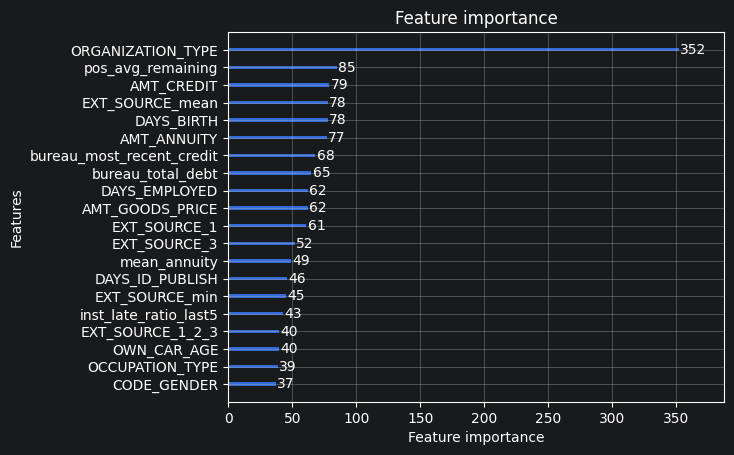

In [19]:
lgb.plot_importance(GBM, max_num_features=20)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


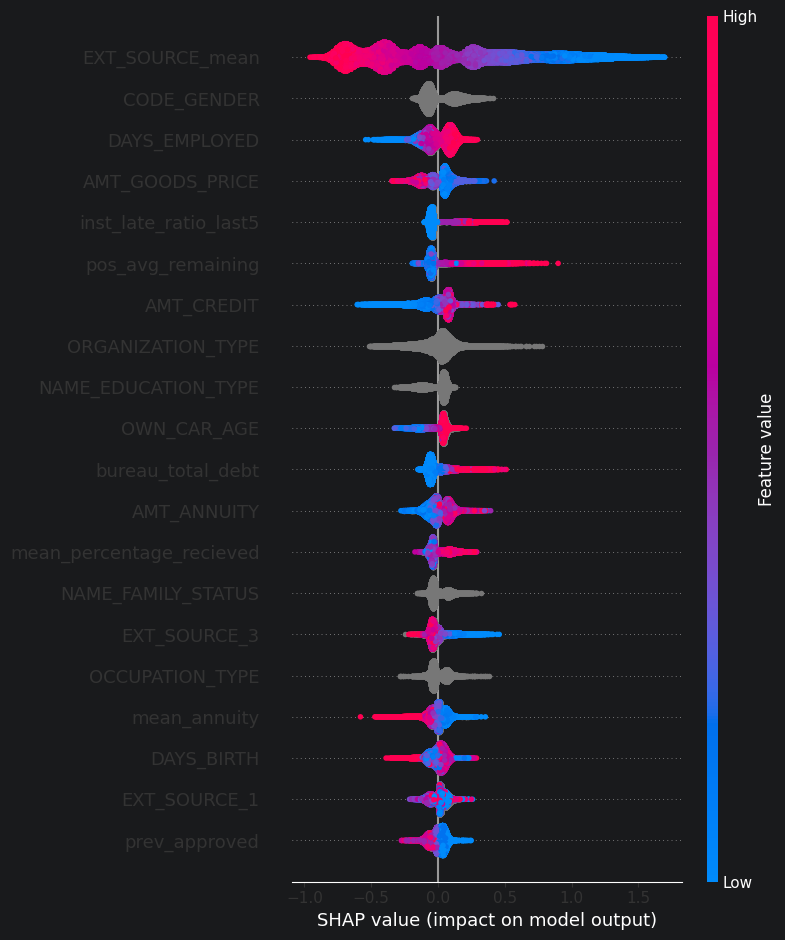

In [20]:
explainer = shap.TreeExplainer(GBM)
shap_values = explainer.shap_values(X)

# Global: welche Features sind insgesamt wichtig
shap.summary_plot(shap_values, X, max_display=20)

In [21]:
def submission(model, X_test_input):
    predictions = model.predict_proba(X_test_input)[:, 1]

    submission = pd.DataFrame({
        "SK_ID_CURR": application_test["SK_ID_CURR"],
        "TARGET": predictions
    })
    return submission

In [22]:
#Besseres Boosting Model:

In [23]:
def objective(trial):
    params = {
        'num_leaves': trial.suggest_int('num_leaves', 20, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.3, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'n_estimators': 2000,
        'random_state': 42,
        'verbose': -1,
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    auc_scores = []
    best_iterations = []

    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
                lgb.log_evaluation(period=-1),
            ],
            categorical_feature=categorical_cols
        )

        preds = model.predict_proba(X_val)[:, 1]
        auc_scores.append(roc_auc_score(y_val, preds))
        best_iterations.append(model.best_iteration_)

    trial.set_user_attr("best_n_estimators", int(np.mean(best_iterations)))
    return np.mean(auc_scores)

In [24]:
def make_objective(X_input):
    def objective(trial):
        params = {
            'num_leaves': trial.suggest_int('num_leaves', 20, 200),
            'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.3, log=True),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'n_estimators': 2000,
            'random_state': 42,
            'verbose': -1,
        }

        cat_cols = [c for c in categorical_cols if c in X_input.columns]
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        auc_scores = []
        best_iterations = []

        for train_idx, val_idx in cv.split(X_input, y):
            X_tr, X_val = X_input.iloc[train_idx], X_input.iloc[val_idx]
            y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

            model = lgb.LGBMClassifier(**params)
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_val, y_val)],
                callbacks=[
                    lgb.early_stopping(stopping_rounds=50, verbose=False),
                    lgb.log_evaluation(period=-1),
                ],
                categorical_feature=cat_cols
            )

            preds = model.predict_proba(X_val)[:, 1]
            auc_scores.append(roc_auc_score(y_val, preds))
            best_iterations.append(model.best_iteration_)

        trial.set_user_attr("best_n_estimators", int(np.mean(best_iterations)))
        return np.mean(auc_scores)

    return objective

In [25]:
study = optuna.create_study(
    direction='maximize',
    storage="sqlite:///lgbm_study.db",
    study_name="lgbm_more_predictors_v2",
    load_if_exists=True
)

study.optimize(objective, n_trials=1)

best_n_estimators = study.best_trial.user_attrs["best_n_estimators"]
print(f"Optimale Anzahl Bäume: {best_n_estimators}")
#[I 2026-05-08 00:12:11,608] Trial 99 finished with value: 0.7749346691050608 and parameters: {'num_leaves': 20, 'learning_rate': 0.20255499763057377, 'min_child_samples': 90, 'subsample': 0.7372678581712692, 'colsample_bytree': 0.8425499076626509, 'reg_alpha': 1.665153387102547, 'reg_lambda': 0.002769154063466205}. Best is trial 87 with value: 0.780503076333318.
#Optimale Anzahl Bäume: 555 study_name: lgbm_v2

[I 2026-05-12 11:15:07,816] Using an existing study with name 'lgbm_more_predictors_v2' instead of creating a new one.
[I 2026-05-12 11:15:28,540] Trial 51 finished with value: 0.7793206277222486 and parameters: {'num_leaves': 29, 'learning_rate': 0.054565768222148286, 'min_child_samples': 86, 'subsample': 0.6837434559051978, 'colsample_bytree': 0.9983138992444068, 'reg_alpha': 1.9205147621356674e-05, 'reg_lambda': 1.3904326442925622e-05}. Best is trial 34 with value: 0.7806149699973525.


Optimale Anzahl Bäume: 518


In [26]:
best_model_lgb = lgb.LGBMClassifier(
    **study.best_params,
    n_estimators=best_n_estimators,
    random_state=42,
    verbose=-1,
)
best_model_lgb.fit(X, y, categorical_feature= categorical_cols)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.050067312933784296
,n_estimators,518
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,79


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

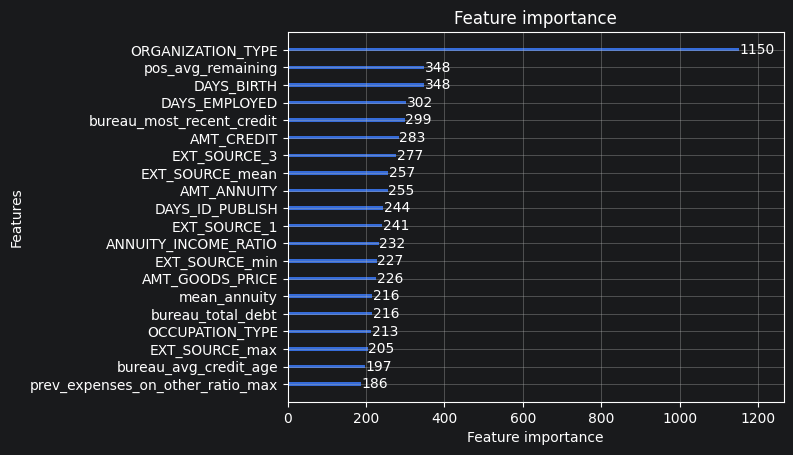

In [27]:
lgb.plot_importance(best_model_lgb, max_num_features=20)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


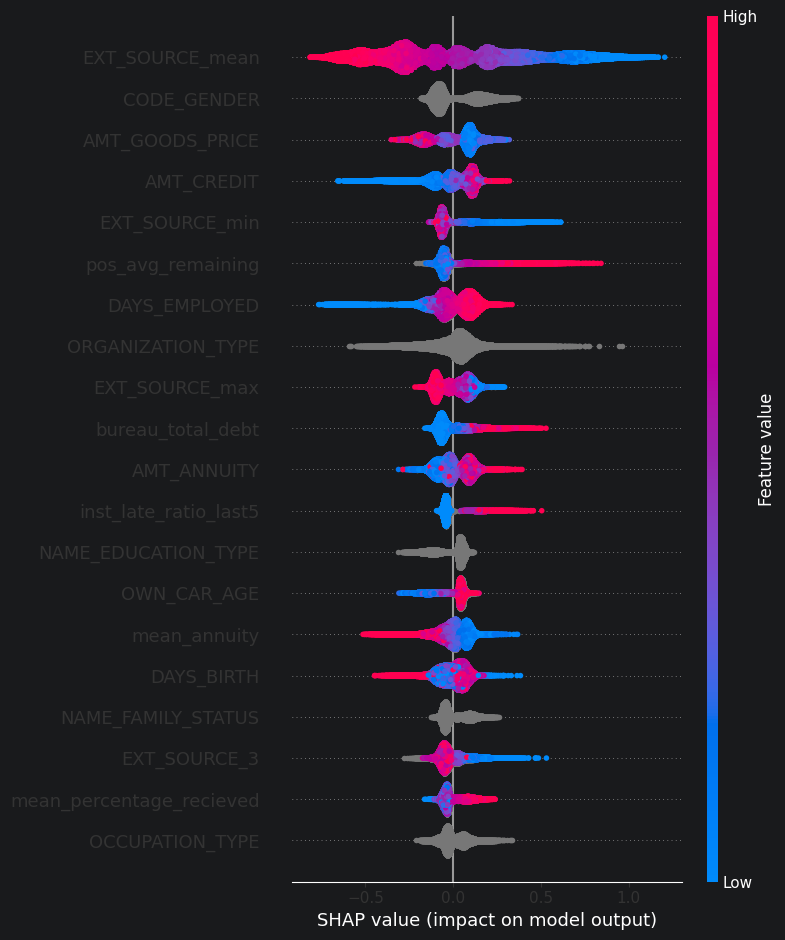

In [28]:
explainer_best = shap.TreeExplainer(best_model_lgb)
shap_val_best = explainer_best.shap_values(X)

shap.summary_plot(shap_val_best, X, max_display=20)

In [29]:
shap_importance = pd.Series(
    np.abs(shap_val_best).mean(axis=0),
    index=X.columns
).sort_values(ascending=False)

# Cutoff anschauen
print(shap_importance.head(40))
print(f"\nFeatures mit SHAP > 0.001: {(shap_importance > 0.001).sum()}")
print(f"Features mit SHAP > 0.005: {(shap_importance > 0.005).sum()}")

EXT_SOURCE_mean                0.347625
CODE_GENDER                    0.110726
AMT_GOODS_PRICE                0.108524
AMT_CREDIT                     0.096133
EXT_SOURCE_min                 0.089538
pos_avg_remaining              0.086181
DAYS_EMPLOYED                  0.086014
ORGANIZATION_TYPE              0.082447
EXT_SOURCE_max                 0.076966
bureau_total_debt              0.073437
AMT_ANNUITY                    0.070150
inst_late_ratio_last5          0.068869
NAME_EDUCATION_TYPE            0.066957
OWN_CAR_AGE                    0.065493
mean_annuity                   0.063560
DAYS_BIRTH                     0.060675
NAME_FAMILY_STATUS             0.059363
EXT_SOURCE_3                   0.057862
mean_percentage_recieved       0.054236
OCCUPATION_TYPE                0.051567
EXT_SOURCE_1                   0.047397
DAYS_ID_PUBLISH                0.046907
EXT_SOURCE_1_2_3               0.043282
bureau_most_recent_credit      0.042621
prev_approved                  0.041930


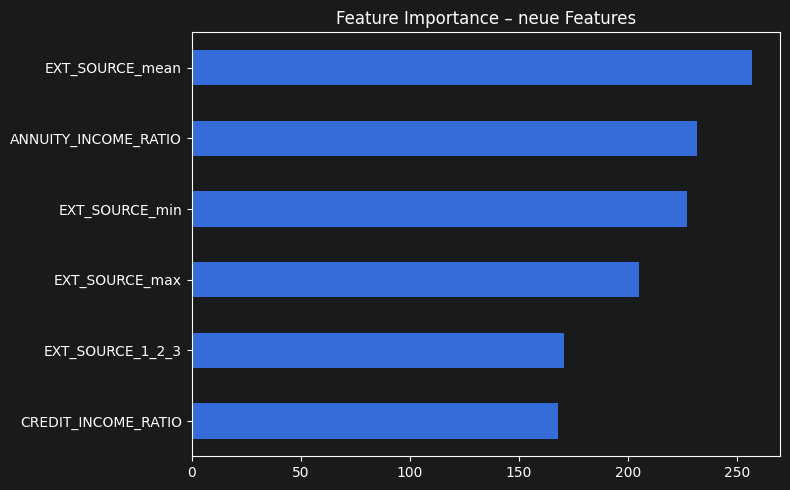

In [30]:
#neue Features
new_features = [
    'EXT_SOURCE_mean', 'EXT_SOURCE_min', 'EXT_SOURCE_max',
    'EXT_SOURCE_1_2_3', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO'
]
fi = pd.Series(
    best_model_lgb.feature_importances_,
    index=X.columns
)[new_features].sort_values()

fi.plot(kind='barh', figsize=(8, 5), title='Feature Importance – neue Features')
plt.tight_layout()
plt.show()

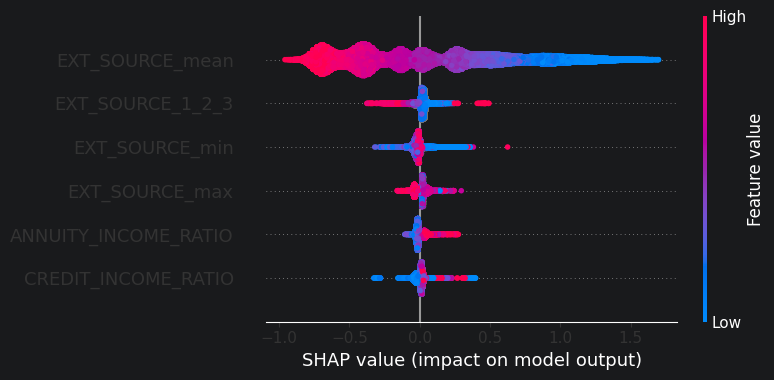

In [31]:
new_idx = [X.columns.tolist().index(f) for f in new_features]
shap.summary_plot(shap_values[:, new_idx], X[new_features])

In [32]:
print(shap_importance[(shap_importance > 0.005) & (shap_importance < 0.015)].sort_values())

FLAG_DOCUMENT_18                0.005063
FLAG_DOCUMENT_16                0.005253
mean_amt_down_payment           0.005348
inst_late_payments              0.005375
AMT_INCOME_TOTAL                0.005526
AMT_REQ_CREDIT_BUREAU_YEAR      0.005649
inst_delay_trend                0.005807
prev_avg_credit_last3           0.005812
bb_active_no_dpd_ratio          0.006588
prev_avg_credit_last5           0.006632
FONDKAPREMONT_MODE              0.006752
cc_avg_balance                  0.006885
inst_avg_delay_last3            0.007292
NAME_HOUSING_TYPE               0.007605
prev_refused_last2              0.007713
HOUR_APPR_PROCESS_START         0.007872
cc_total_payment                0.007874
YEARS_BEGINEXPLUATATION_MEDI    0.008242
DEF_60_CNT_SOCIAL_CIRCLE        0.008318
WALLSMATERIAL_MODE              0.008680
cc_active_count                 0.008963
bb_active_no_dpd_months         0.009009
bureau_oldest_credit            0.009231
pos_avg_Fortschritt             0.009563
inst_avg_delay  

In [33]:
study.best_params

{'num_leaves': 31,
 'learning_rate': 0.050067312933784296,
 'min_child_samples': 79,
 'subsample': 0.9960442710158228,
 'colsample_bytree': 0.6386821806158813,
 'reg_alpha': 2.3155178547335092e-06,
 'reg_lambda': 0.00036079392119827054}

In [34]:
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(X, y, test_size=0.2, random_state=42)

#best_model = lgb.LGBMClassifier(**study.best_params, n_estimators=1000, random_state=42)
#best_model.fit(
 #   X_train_final, y_train_final,
 #   eval_set=[(X_val_final, y_val_final)],
 #   callbacks=[lgb.early_stopping(stopping_rounds=50)]
#)

In [35]:
print(set(X.columns) - set(X_test.columns))
print(set(X_test.columns) - set(X.columns))

set()
set()


In [36]:
#submission3 = submission(best_model_lgb, X_test)
#submission3.to_csv("submission9.csv", index=False)

In [37]:
#mal nur die wichtigsten Features
top_features = shap_importance[np.abs(shap_importance) > 0.005].index.tolist()
print(len(top_features))

X_train_reduced = X[top_features]
application_test_reduced = application_test[top_features]
categorical_cols_reduced = [c for c in categorical_cols if c in top_features]

98


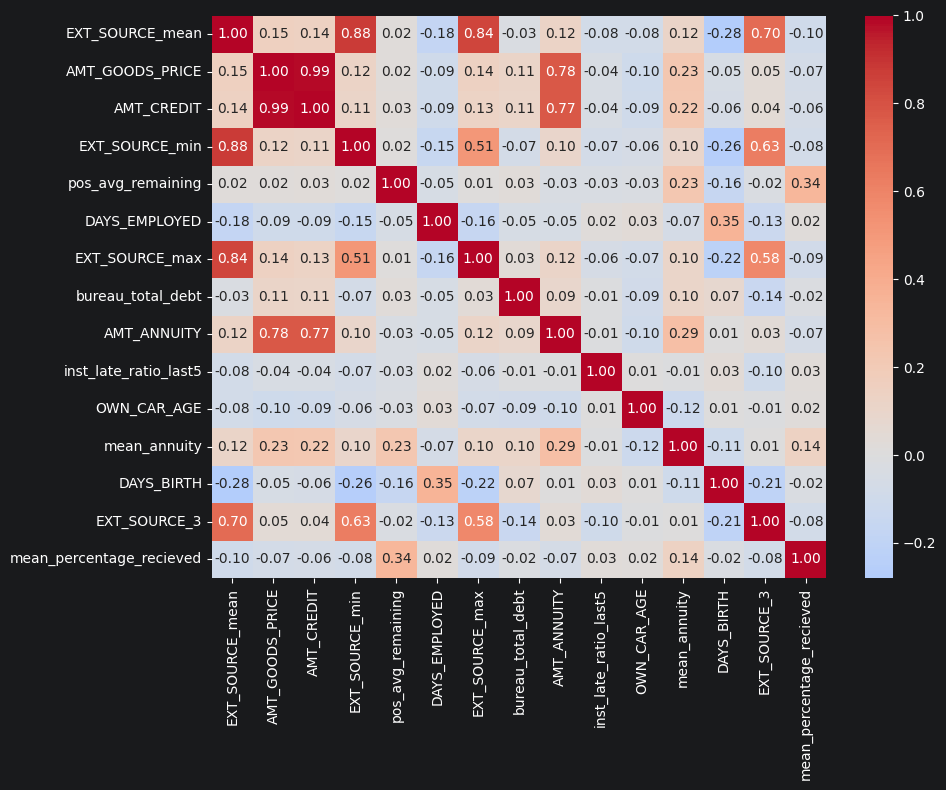

In [38]:
top_20 = shap_importance.head(20).index.tolist()
top_20_numeric = X_train_reduced[top_20].select_dtypes(include='number').columns.tolist()
corr = X_train_reduced[top_20_numeric].corr()

import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.tight_layout()
plt.show()

In [39]:
def objective_reduced(trial):
    params = {
        'num_leaves': trial.suggest_int('num_leaves', 20, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'n_estimators': 2000,
        'random_state': 42,
        'verbose': -1,
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    auc_scores = []
    best_iterations = []

    for train_idx, val_idx in cv.split(X_train_reduced, y):
        X_tr, X_val = X_train_reduced.iloc[train_idx], X_train_reduced.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
                lgb.log_evaluation(period=-1),
            ],
            categorical_feature=categorical_cols_reduced,
        )

        preds = model.predict_proba(X_val)[:, 1]
        auc_scores.append(roc_auc_score(y_val, preds))
        best_iterations.append(model.best_iteration_)

    trial.set_user_attr("best_n_estimators", int(np.mean(best_iterations)))
    return np.mean(auc_scores)

In [40]:
study_reduced = optuna.create_study(
    direction='maximize',
    storage="sqlite:///lgbm_study.db",
    study_name="lgbm_reduced_v3",
    load_if_exists=True
)

study_reduced.optimize(objective_reduced, n_trials=1)

best_n_estimators = study_reduced.best_trial.user_attrs["best_n_estimators"]
print(f"Optimale Anzahl Bäume: {best_n_estimators}")

[I 2026-05-12 11:17:49,815] Using an existing study with name 'lgbm_reduced_v3' instead of creating a new one.
[I 2026-05-12 11:18:54,178] Trial 100 finished with value: 0.7825194585387805 and parameters: {'num_leaves': 39, 'learning_rate': 0.016493986435363723, 'min_child_samples': 59, 'subsample': 0.6559368825731985, 'colsample_bytree': 0.5944109851243655, 'reg_alpha': 1.23084324834188e-06, 'reg_lambda': 1.4633600805842002}. Best is trial 100 with value: 0.7825194585387805.


Optimale Anzahl Bäume: 1313


In [41]:
best_model_reduced = lgb.LGBMClassifier(
    **study_reduced.best_params,
    n_estimators=best_n_estimators,
    random_state=42,
    verbose=-1,
)
best_model_reduced.fit(X_train_reduced, y, categorical_feature= categorical_cols_reduced)

,boosting_type,'gbdt'
,num_leaves,39
,max_depth,-1
,learning_rate,0.016493986435363723
,n_estimators,1313
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,59


In [42]:
#submission_reduced = submission(best_model_reduced, application_test_reduced)
#submission_reduced.to_csv("submission_reduced3.csv", index=False)

In [43]:
corr_matrix = X_train_reduced.select_dtypes(include='number').corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Alle Paare über 0.85
high_corr_pairs = [(col, row, upper.loc[row, col])
                   for col in upper.columns
                   for row in upper.index
                   if upper.loc[row, col] > 0.85]

for col1, col2, corr_val in sorted(high_corr_pairs, key=lambda x: -x[2]):
    print(f"{col1} -- {col2}: {corr_val:.3f}")

AMT_CREDIT -- AMT_GOODS_PRICE: 0.987
max_amt_application -- max_amt_credit: 0.986
EXT_SOURCE_1_2_3 -- EXT_SOURCE_mean: 0.931
inst_avg_delay_last3 -- inst_avg_delay_last2: 0.930
prev_avg_credit_last3 -- prev_avg_credit_last5: 0.922
EXT_SOURCE_1_2_3 -- EXT_SOURCE_min: 0.918
inst_avg_delay_last3 -- inst_avg_delay_last5: 0.917
prev_refused_last2 -- prev_refused_last3: 0.896
prev_expenses_on_other_ratio_mean -- mean_percentage_recieved: 0.894
prev_refused_last5 -- prev_refused_last3: 0.888
inst_late_ratio_last3 -- inst_late_ratio_last5: 0.882
EXT_SOURCE_min -- EXT_SOURCE_mean: 0.880
cc_avg_balance -- cc_max_balance: 0.875
mean_amt_down_payment -- max_amt__down_payment: 0.871
DEF_60_CNT_SOCIAL_CIRCLE -- DEF_30_CNT_SOCIAL_CIRCLE: 0.861
bureau_max_credit -- bureau_total_credit: 0.855
cc_max_utilization -- cc_avg_utilization: 0.850


In [44]:
pairs = [
    ('AMT_CREDIT', 'AMT_GOODS_PRICE'),
    ('max_amt_application', 'max_amt_credit'),
    ('EXT_SOURCE_1_2_3', 'EXT_SOURCE_mean'),
    ('EXT_SOURCE_1_2_3', 'EXT_SOURCE_min'),
    ('prev_expenses_on_other_ratio_mean', 'mean_percentage_recieved'),
    ('EXT_SOURCE_min', 'EXT_SOURCE_mean'),
    ('cc_avg_balance', 'cc_max_balance'),
    ('DEF_60_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE'),
    ('cc_max_utilization', 'cc_avg_utilization'),
]

columns_to_drop = []
for f1, f2 in pairs:
    s1 = shap_importance.get(f1, 0)
    s2 = shap_importance.get(f2, 0)
    drop = f1 if s1 < s2 else f2
    columns_to_drop.append(drop)
    print(f"{f1} ({s1:.4f}) vs {f2} ({s2:.4f}) → drop: {drop}")

AMT_CREDIT (0.0961) vs AMT_GOODS_PRICE (0.1085) → drop: AMT_CREDIT
max_amt_application (0.0120) vs max_amt_credit (0.0151) → drop: max_amt_application
EXT_SOURCE_1_2_3 (0.0433) vs EXT_SOURCE_mean (0.3476) → drop: EXT_SOURCE_1_2_3
EXT_SOURCE_1_2_3 (0.0433) vs EXT_SOURCE_min (0.0895) → drop: EXT_SOURCE_1_2_3
prev_expenses_on_other_ratio_mean (0.0159) vs mean_percentage_recieved (0.0542) → drop: prev_expenses_on_other_ratio_mean
EXT_SOURCE_min (0.0895) vs EXT_SOURCE_mean (0.3476) → drop: EXT_SOURCE_min
cc_avg_balance (0.0069) vs cc_max_balance (0.0113) → drop: cc_avg_balance
DEF_60_CNT_SOCIAL_CIRCLE (0.0083) vs DEF_30_CNT_SOCIAL_CIRCLE (0.0266) → drop: DEF_60_CNT_SOCIAL_CIRCLE
cc_max_utilization (0.0256) vs cc_avg_utilization (0.0267) → drop: cc_max_utilization


In [45]:
columns_to_drop = list(set(columns_to_drop))  # Duplikate entfernen
X_train_reduced_further = X_train_reduced.drop(columns=columns_to_drop)
application_test_reduced_further = application_test_reduced.drop(columns=columns_to_drop)
X_train_reduced_further.shape

(307511, 90)

In [46]:
study_reduced_further = optuna.create_study(
    direction='maximize',
    storage="sqlite:///lgbm_study.db",
    study_name="lgbm_reduced_further_v1",
    load_if_exists=True
)

study_reduced_further.optimize(make_objective(X_train_reduced_further), n_trials=1)

best_n_estimators = study.best_trial.user_attrs["best_n_estimators"]
print(f"Optimale Anzahl Bäume: {best_n_estimators}")

[I 2026-05-12 11:19:22,126] Using an existing study with name 'lgbm_reduced_further_v1' instead of creating a new one.
[I 2026-05-12 11:19:38,454] Trial 110 finished with value: 0.7796953661828887 and parameters: {'num_leaves': 28, 'learning_rate': 0.05836778477947778, 'min_child_samples': 92, 'subsample': 0.5784168150488769, 'colsample_bytree': 0.7019919662517732, 'reg_alpha': 3.385449243492858e-07, 'reg_lambda': 0.16148591318136735}. Best is trial 62 with value: 0.7797445033202127.


Optimale Anzahl Bäume: 518


In [47]:
categorical_cols_reduced_further = [c for c in categorical_cols if c in X_train_reduced_further.columns]

In [48]:
best_model_reduced_further = lgb.LGBMClassifier(
    **study_reduced_further.best_params,
    n_estimators=best_n_estimators,
    random_state=42,
    verbose=-1,
)
best_model_reduced_further.fit(X_train_reduced_further, y, categorical_feature= categorical_cols_reduced_further)

,boosting_type,'gbdt'
,num_leaves,28
,max_depth,-1
,learning_rate,0.05331067383324269
,n_estimators,518
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,93


In [49]:
#submission_reduced_further = submission(best_model_reduced_further, application_test_reduced_further)
#submission_reduced_further.to_csv("submission_reduced_further.csv", index=False)

In [50]:
#Baseline XGBoost

In [51]:
#submission4 = submission(xgb_model)
#submission4.to_csv("submission4.csv", index=False)

In [52]:
xgb_model = xgb.XGBClassifier(
    n_estimators=1000,        # Anzahl der Bäume
    learning_rate=0.05,       # Schrittweite (Eta)
    max_depth=6,              # Tiefe der Bäume
    subsample=0.8,            # Anteil der Daten pro Baum (Reihe)
    colsample_bytree=0.8,     # Anteil der Features pro Baum (Spalte)
    tree_method='hist',       # Nutzt Histogramm-Methode (viel schneller, ähnlich wie LightGBM)
    random_state=42,
    use_label_encoder=False,
    enable_categorical=True,
)

# Training mit Early Stopping
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)], # Validierung auf "unbekannten" Daten
    verbose=100
)

XGBoostError: [11:19:48] /Users/runner/work/xgboost/xgboost/src/data/gradient_index.h:99: Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`
Stack trace:
  [bt] (0) 1   libxgboost.dylib                    0x0000000116127dd8 dmlc::LogMessageFatal::~LogMessageFatal() + 124
  [bt] (1) 2   libxgboost.dylib                    0x000000011632cd2c void xgboost::GHistIndexMatrix::SetIndexData<xgboost::data::EncColumnarAdapterBatchImpl<xgboost::CatAccessor>, unsigned int, void xgboost::GHistIndexMatrix::PushBatchImpl<xgboost::data::EncColumnarAdapterBatchImpl<xgboost::CatAccessor>, xgboost::data::IsValidFunctor&>(xgboost::Context const*, xgboost::data::EncColumnarAdapterBatchImpl<xgboost::CatAccessor> const&, unsigned long, xgboost::data::IsValidFunctor&, xgboost::common::Span<xgboost::FeatureType const, 18446744073709551615ul>)::'lambda'(xgboost::data::EncColumnarAdapterBatchImpl<xgboost::CatAccessor>, xgboost::data::IsValidFunctor&), xgboost::data::IsValidFunctor&>(xgboost::common::Span<xgboost::data::IsValidFunctor&, 18446744073709551615ul>, unsigned long, xgboost::common::Span<xgboost::FeatureType const, 18446744073709551615ul>, unsigned long, xgboost::data::EncColumnarAdapterBatchImpl<xgboost::CatAccessor> const&, xgboost::data::IsValidFunctor&, unsigned long, void xgboost::GHistIndexMatrix::PushBatchImpl<xgboost::data::EncColumnarAdapterBatchImpl<xgboost::CatAccessor>, xgboost::data::IsValidFunctor&>(xgboost::Context const*, xgboost::data::EncColumnarAdapterBatchImpl<xgboost::CatAccessor> const&, unsigned long, xgboost::data::IsValidFunctor&, xgboost::common::Span<xgboost::FeatureType const, 18446744073709551615ul>)::'lambda'(xgboost::data::EncColumnarAdapterBatchImpl<xgboost::CatAccessor>, xgboost::data::IsValidFunctor&)&&) + 328
  [bt] (2) 3   libxgboost.dylib                    0x0000000116329df4 void xgboost::GHistIndexMatrix::PushBatchImpl<xgboost::data::EncColumnarAdapterBatchImpl<xgboost::CatAccessor>, xgboost::data::IsValidFunctor&>(xgboost::Context const*, xgboost::data::EncColumnarAdapterBatchImpl<xgboost::CatAccessor> const&, unsigned long, xgboost::data::IsValidFunctor&, xgboost::common::Span<xgboost::FeatureType const, 18446744073709551615ul>) + 424
  [bt] (3) 4   libxgboost.dylib                    0x0000000116329938 void xgboost::GHistIndexMatrix::PushAdapterBatch<xgboost::data::EncColumnarAdapterBatchImpl<xgboost::CatAccessor>>(xgboost::Context const*, unsigned long, unsigned long, xgboost::data::EncColumnarAdapterBatchImpl<xgboost::CatAccessor> const&, float, xgboost::common::Span<xgboost::FeatureType const, 18446744073709551615ul>, double, unsigned long long) + 296
  [bt] (4) 5   libxgboost.dylib                    0x0000000116339b58 xgboost::data::IterativeDMatrix::InitFromCPU(xgboost::Context const*, xgboost::BatchParam const&, xgboost::data::DataIterProxy<void (void*), int (void*)>&&, float, std::__1::shared_ptr<xgboost::DMatrix>) + 2268
  [bt] (5) 6   libxgboost.dylib                    0x0000000116338e20 xgboost::data::IterativeDMatrix::IterativeDMatrix(void*, void*, std::__1::shared_ptr<xgboost::DMatrix>, void (*)(void*), int (*)(void*), float, int, int, long long) + 908
  [bt] (6) 7   libxgboost.dylib                    0x00000001162b8414 xgboost::DMatrix* xgboost::DMatrix::Create<void*, void*, void (void*), int (void*)>(void*, void*, std::__1::shared_ptr<xgboost::DMatrix>, void (*)(void*), int (*)(void*), float, int, int, long long) + 152
  [bt] (7) 8   libxgboost.dylib                    0x00000001161321ac XGQuantileDMatrixCreateFromCallback + 520
  [bt] (8) 9   libffi.dylib                        0x000000019d05a050 ffi_call_SYSV + 80



In [53]:
#XGBoost kann inf Werte nicht

In [54]:
inf_cols = [col for col in numerical_cols if np.isinf(X[col]).any()]
print(inf_cols)

['prev_expenses_on_other_ratio_mean']


In [55]:
X = X.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

In [56]:
def objectiveXGB(trial):
    params = {
        'n_estimators': 1000,
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'tree_method': 'hist',
        'enable_categorical': True,
        'random_state': 42,
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    auc_scores = []
    best_iterations = []

    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = xgb.XGBClassifier(**params, early_stopping_rounds=50)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        preds = model.predict_proba(X_val)[:, 1]
        auc_scores.append(roc_auc_score(y_val, preds))
        best_iterations.append(model.best_iteration)

    trial.set_user_attr("best_n_estimators", int(np.mean(best_iterations)))
    return np.mean(auc_scores)

In [57]:
studyXG = optuna.create_study(
    direction='maximize',
    storage="sqlite:///xgb_study.db",
    study_name="xgb_more_predictors",
    load_if_exists=True
)
studyXG.optimize(objectiveXGB, n_trials=1)

print("Beste Parameter:", studyXG.best_params)
print("Bester Score:", studyXG.best_value)
print("Optimale Bäume:", studyXG.best_trial.user_attrs["best_n_estimators"])

[I 2026-05-12 11:20:37,615] Using an existing study with name 'xgb_more_predictors' instead of creating a new one.
[I 2026-05-12 11:33:55,221] Trial 29 finished with value: 0.781885748286468 and parameters: {'max_depth': 6, 'learning_rate': 0.013204252212004457, 'subsample': 0.7624147326631179, 'colsample_bytree': 0.7315461179332424, 'min_child_weight': 11, 'gamma': 1.0684471630861425e-06, 'reg_alpha': 9.967096335443986e-08, 'reg_lambda': 9.08356348504156}. Best is trial 25 with value: 0.7837995824997183.


Beste Parameter: {'max_depth': 7, 'learning_rate': 0.02350172570681411, 'subsample': 0.9545020011642269, 'colsample_bytree': 0.7245633594750509, 'min_child_weight': 18, 'gamma': 7.557124097398162e-07, 'reg_alpha': 8.980702169885854e-08, 'reg_lambda': 6.2688592620204195}
Bester Score: 0.7837995824997183
Optimale Bäume: 905


In [58]:
#X_tr, X_val, y_tr, y_val = train_test_split(
#    X, y, test_size=0.1, stratify=y, random_state=42
#)

#best_model_XG = xgb.XGBClassifier(
#    **studyXG.best_params,
#    n_estimators=1000,
#    random_state=42,
#    tree_method="hist",
#    enable_categorical=True,
#    early_stopping_rounds=50
#)
#best_model_XG.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=100)
#print(best_model_XG.best_iteration)

In [59]:
best_n_estimators_xgb = studyXG.best_trial.user_attrs["best_n_estimators"]

best_model_xgb = xgb.XGBClassifier(
    **studyXG.best_params,
    n_estimators=best_n_estimators_xgb,
    tree_method='hist',
    enable_categorical=True,
    random_state=42,
)
best_model_xgb.fit(X, y)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.7245633594750509
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegress

In [60]:
#submission5 = submission(best_model_xgb, X_test)
#submission5.to_csv("submission_XG.csv", index=False)

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

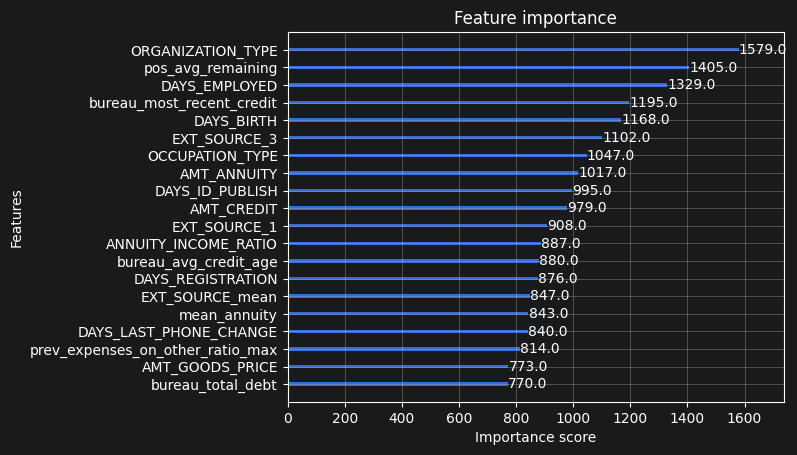

In [61]:
xgb.plot_importance(best_model_xgb, max_num_features=20)

In [62]:
#Mal lgb und XGB zusammen

In [63]:
pred_lgb = best_model_lgb.predict_proba(X_test)[:, 1]
pred_xgb = best_model_xgb.predict_proba(X_test)[:, 1]
pred_ensemble = 0.5 * pred_lgb + 0.5 * pred_xgb

submission_ensemble = pd.DataFrame({
    "SK_ID_CURR": application_test["SK_ID_CURR"],
    "TARGET": pred_ensemble
})
#submission_ensemble.to_csv("submission_ensemble.csv", index=False)

In [64]:
#Catboost

In [65]:
X_cat = X.copy()
X_test_cat = X_test.copy()

In [66]:
cat_cols = X_cat.select_dtypes(include='category').columns.tolist()

for col in cat_cols:
    X_cat[col] = X_cat[col].astype(str).replace({'nan': 'Unknown', 'None': 'Unknown', '<NA>': 'Unknown'})
    X_test_cat[col] = X_test_cat[col].astype(str).replace({'nan': 'Unknown', 'None': 'Unknown', '<NA>': 'Unknown'})


In [67]:
cat_features_idx = [X.columns.get_loc(col) for col in cat_cols]

In [68]:
print(X_cat.dtypes[cat_cols])

NAME_CONTRACT_TYPE            object
CODE_GENDER                   object
FLAG_OWN_CAR                  object
FLAG_OWN_REALTY               object
NAME_TYPE_SUITE               object
NAME_INCOME_TYPE              object
NAME_EDUCATION_TYPE           object
NAME_FAMILY_STATUS            object
NAME_HOUSING_TYPE             object
OCCUPATION_TYPE               object
WEEKDAY_APPR_PROCESS_START    object
ORGANIZATION_TYPE             object
FONDKAPREMONT_MODE            object
HOUSETYPE_MODE                object
WALLSMATERIAL_MODE            object
EMERGENCYSTATE_MODE           object
dtype: object


In [69]:
def objectiveCB(trial):
    params = {
        'iterations': 1000,
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'random_seed': 42,
        'verbose': 0,
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    auc_scores = []
    best_iterations = []

    for train_idx, val_idx in cv.split(X_cat, y):
        X_tr, X_val = X_cat.iloc[train_idx], X_cat.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = CatBoostClassifier(**params, early_stopping_rounds=50)
        model.fit(
            X_tr, y_tr,
            eval_set=(X_val, y_val),
            cat_features=cat_features_idx,
        )

        preds = model.predict_proba(X_val)[:, 1]
        auc_scores.append(roc_auc_score(y_val, preds))
        best_iterations.append(model.best_iteration_)

    trial.set_user_attr("best_n_estimators", int(np.mean(best_iterations)))
    return np.mean(auc_scores)

In [70]:
studyCB = optuna.create_study(
    direction='maximize',
    storage="sqlite:///cb_study.db",
    study_name="catboost_v1",
    load_if_exists=True
)
studyCB.optimize(objectiveCB, n_trials=1)

[I 2026-05-12 11:35:08,938] Using an existing study with name 'catboost_v1' instead of creating a new one.
[I 2026-05-12 11:42:25,041] Trial 52 finished with value: 0.7812776785804538 and parameters: {'depth': 8, 'learning_rate': 0.045263708973432695, 'l2_leaf_reg': 1.9366047454663273, 'subsample': 0.868421711775581, 'colsample_bylevel': 0.8200571157206441}. Best is trial 25 with value: 0.7813446131048218.


In [73]:
best_n_estimators_cb = studyCB.best_trial.user_attrs["best_n_estimators"]

best_model_cb = CatBoostClassifier(
    **studyCB.best_params,
    iterations=best_n_estimators_cb,
    random_seed=42,
    verbose=0
)
best_model_cb.fit(X_cat, y, cat_features=cat_features_idx)

CatBoostClassifier(colsample_bylevel=0.7854696902116826, depth=8, iterations=969, l2_leaf_reg=6.432665757591312, learning_rate=0.03976785617290203, random_seed=42, subsample=0.836120913927535, verbose=0)

In [74]:
submission_cat = submission(best_model_cb, X_test_cat)
submission_cat.to_csv("submission_cat.csv", index=False)

In [ ]:
#Ensemble, alle zusammen

In [76]:
pred_lgb = best_model_lgb.predict_proba(X_test)[:, 1]
pred_xgb = best_model_xgb.predict_proba(X_test)[:, 1]
pred_cb = best_model_cb.predict_proba(X_test_cat)[:, 1]
pred_ensemble_all = (pred_lgb + pred_xgb + pred_cb) / 3

In [77]:
submission_ensemble_all = pd.DataFrame({
    "SK_ID_CURR": application_test["SK_ID_CURR"],
    "TARGET": pred_ensemble_all
})
submission_ensemble.to_csv("submission_ensemble_all.csv", index=False)